In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
dataframe_NH = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

gas_R_half_NH = dataframe_NH['gas_r_half']

gals_NH = dataframe_NH['Gal_number']

chosen_gals_NH = np.loadtxt('/mnt/users/darnej/MPhys/Chosen_galaxies_final_NH.txt')

gas_R_half_NH = gas_R_half_NH[np.isin(gals_NH, chosen_gals_NH)]

dataframe_TNG = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gas_R_half_TNG = dataframe_TNG['gas_r_half']

gals_TNG = dataframe_TNG['gal_number']

chosen_gals_TNG = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_final_TNG.txt')

gas_R_half_TNG = gas_R_half_TNG[np.isin(gals_TNG, chosen_gals_TNG)]



In [3]:
#NH
accels_NH = defaultdict(list)

files = glob.glob('/mnt/users/darnej/MPhys/RAR_for_all/results_for*')

num = 0
i = 0

while num < 5:

    gal = int(chosen_gals_NH[i])

    print(gal)

    file = [f for f in files if f'_{gal}.csv' in f][0]
    
    RAR = pd.read_csv(file)

    g_bar = RAR['mean_acc_bar'].to_numpy()
    r = RAR['mean_r'].to_numpy()
    g_tot = RAR['total_mean_acc_bar'].to_numpy()
    g_rot = RAR['mean_acc_obs'].to_numpy()
    
    try:
        g_obs = RAR['g_obs'].to_numpy()
        num += 1
        i += 1
        accels_NH[gal] = [g_bar, r, g_tot, g_rot, g_obs]
    except:
        i += 1
        print('No g_obs')
        continue


files = glob.glob('/mnt/users/darnej/MPhys/pytree_results/pytree_results*')

for gal in accels_NH:

    gal = int(gal)

    file = [f for f in files if f'_{gal}.csv' in f][0]

    pytree = pd.read_csv(file)

    g_bar_tree = pytree['mean_a_r_py'].to_numpy()
    r_tree = pytree['mean_r'].to_numpy()
    g_tot_tree = pytree['mean_a_r_total_py'].to_numpy()

    accels_NH[gal].extend([g_bar_tree, r_tree, g_tot_tree])



1
No g_obs
2
7
8
9
No g_obs
11
12


In [4]:
#TNG
accels_TNG = defaultdict(list)

files = glob.glob('/mnt/users/darnej/MPhys/TNG-50/RAR_for_all_TNG/results_for*')

num = 0
i = 0

while num < 5:

    gal = int(chosen_gals_TNG[i])

    print(gal)

    file = [f for f in files if f'_{gal}.csv' in f][0]
    
    RAR = pd.read_csv(file)

    g_bar = RAR['mean_acc_bar'].to_numpy()
    r = RAR['mean_r'].to_numpy()
    g_tot = RAR['total_mean_acc_bar'].to_numpy()
    g_rot = RAR['mean_acc_obs'].to_numpy()
    
    try:
        g_obs = RAR['g_obs'].to_numpy()
        num += 1
        i += 1
        accels_TNG[gal] = [g_bar, r, g_tot, g_rot, g_obs]
    except:
        i += 1
        print('No g_obs')
        continue


files = glob.glob('/mnt/users/darnej/MPhys/TNG-50/pytree_results/pytree_results*')

for gal in accels_TNG:

    gal = int(gal)

    file = [f for f in files if f'_{gal}.csv' in f][0]

    pytree = pd.read_csv(file)

    g_bar_tree = pytree['mean_a_r_py'].to_numpy()
    r_tree = pytree['mean_r'].to_numpy()
    g_tot_tree = pytree['mean_a_r_total_py'].to_numpy()

    accels_TNG[gal].extend([g_bar_tree, r_tree, g_tot_tree])



220597
220598
220599
220600
220602


/tmp/ipykernel_3601930/4271919117.py:49: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[j,i].axvline(float(gas_R_half_NH[mask]), color = 'black', linestyle = ':', label = r'$R_{1/2}^{gas}$' if i == 0 else None, linewidth = 2)
/tmp/ipykernel_3601930/4271919117.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax[j,i].axvline(float(gas_R_half_TNG[mask]), color = 'black', linestyle = ':', label = r'$R_{1/2}^{gas}$', linewidth = 2)


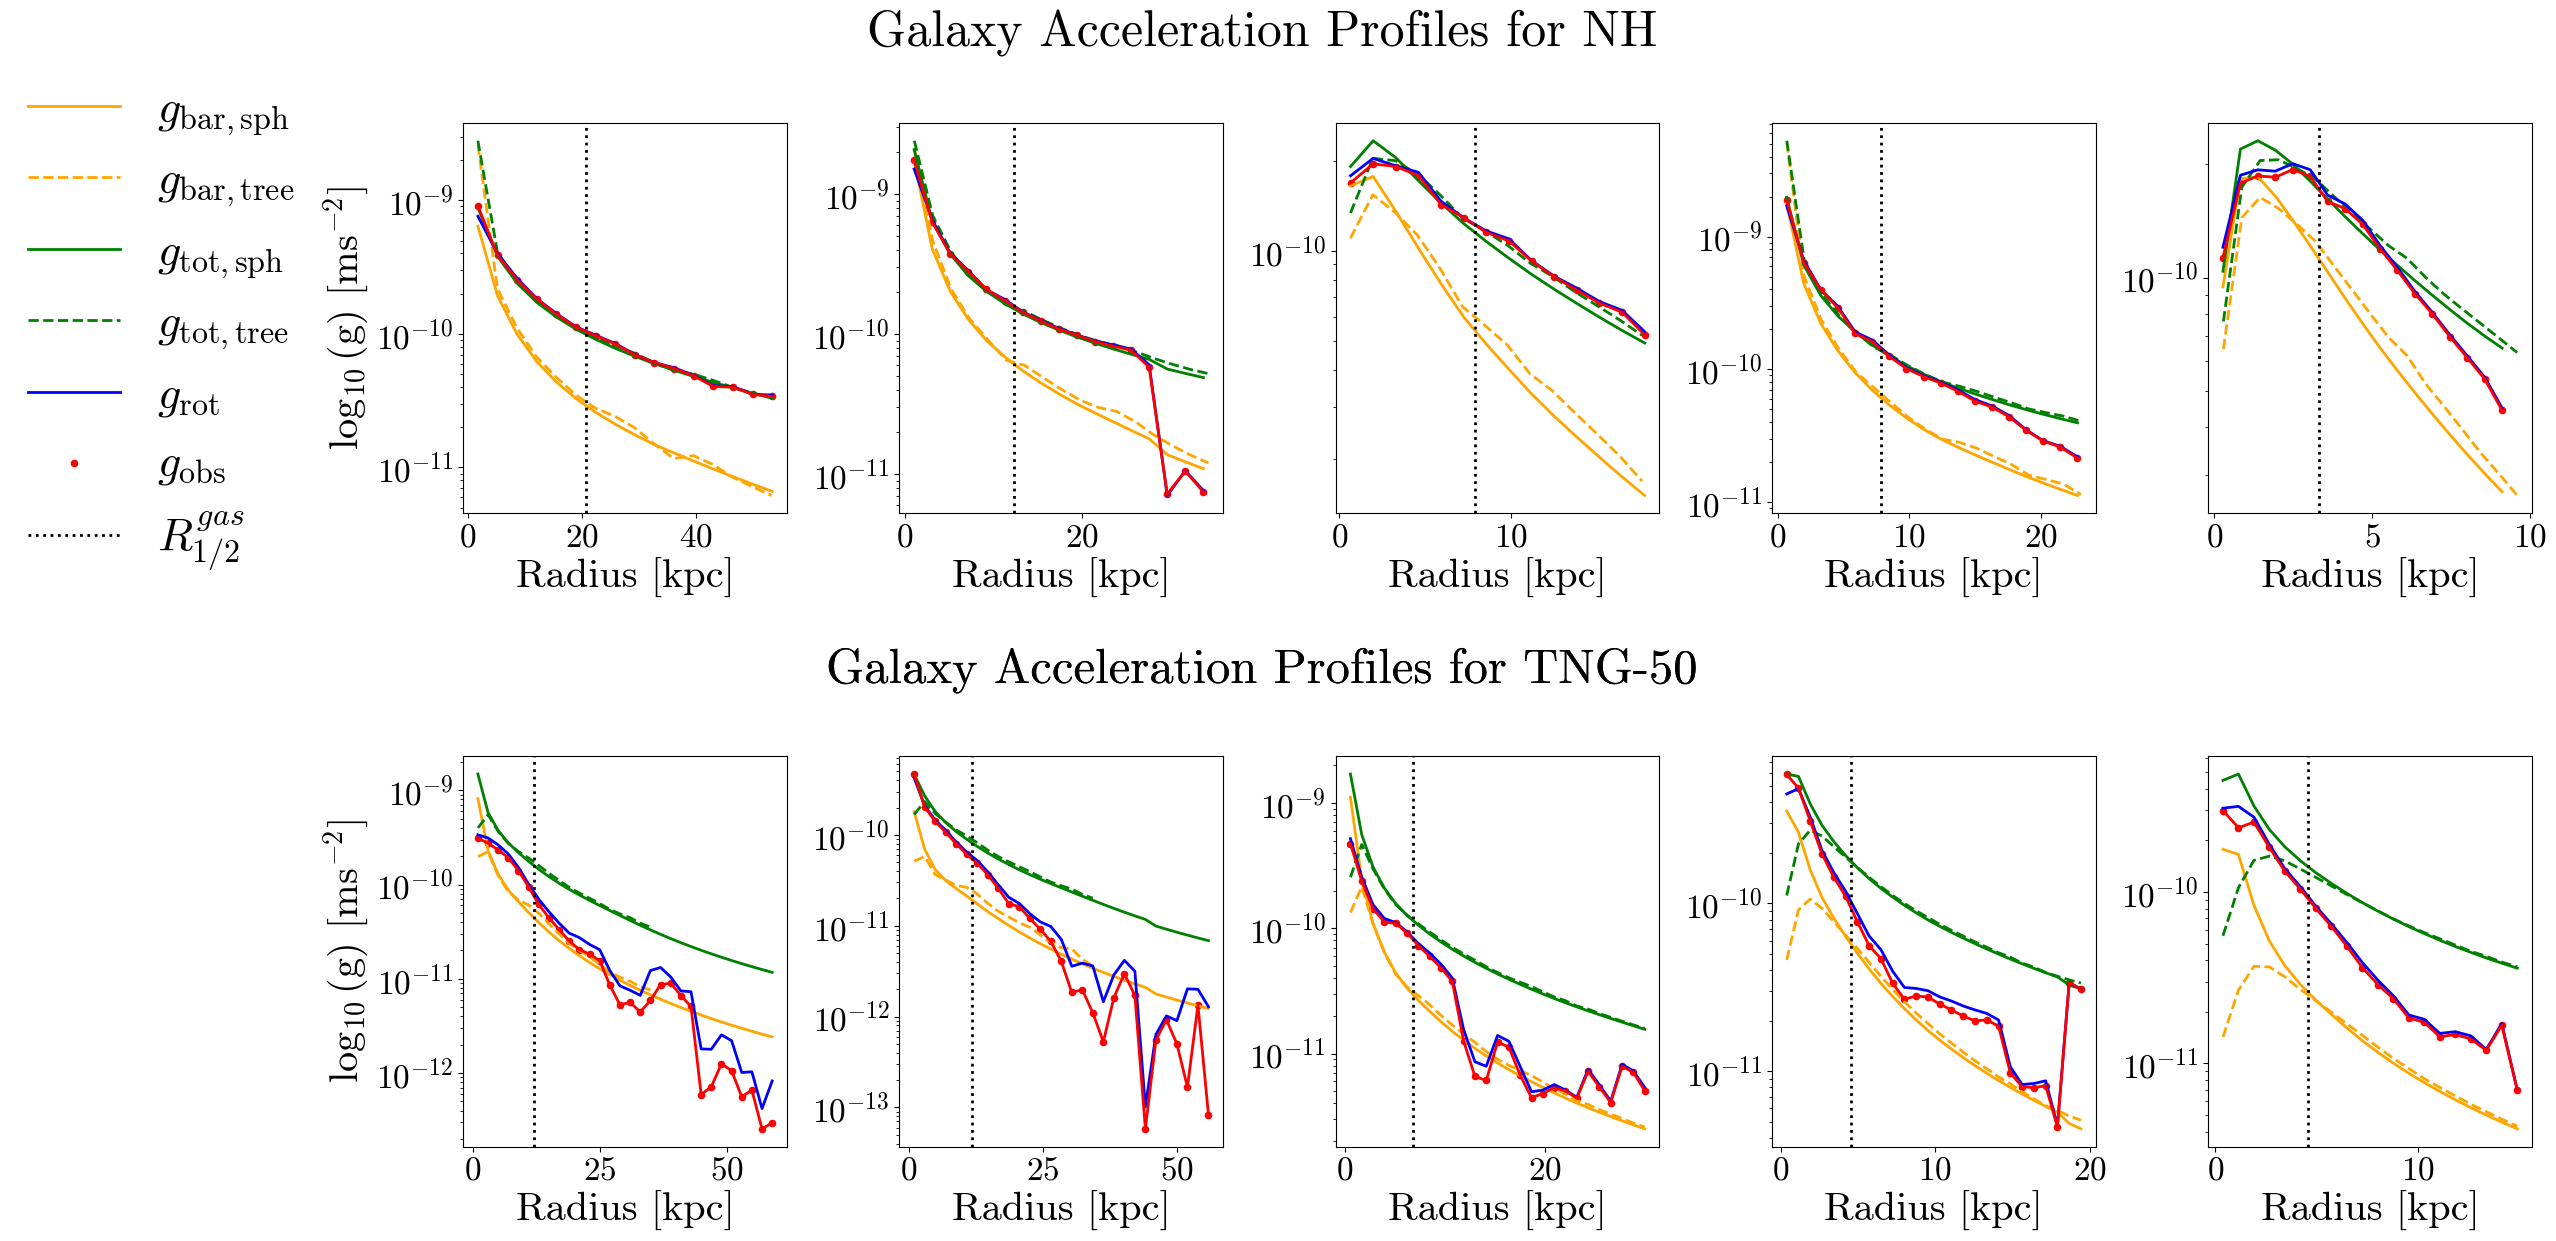

In [27]:

fig, ax = plt.subplots(2, 5, figsize = (26,12))

fig.suptitle('Galaxy Acceleration Profiles for NH', fontsize = 36, y = 1.03)

plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 24  # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 24   # Increase y-axis tick font size

for j in range(2):

    if j == 0:
        accels = accels_NH
    else:
        accels = accels_TNG

    for i in range(5):
        gal = list(accels.keys())[i]
        g_bar, r, g_tot, g_rot, g_obs, g_bar_tree, r_tree, g_tot_tree = accels[int(gal)]

        mask = np.isnan(g_obs)
        g_obs = g_obs[~mask]
        r = r[~mask]
        g_bar = g_bar[~mask]
        g_tot = g_tot[~mask]
        g_rot = g_rot[~mask]
        g_bar_tree = g_bar_tree[~mask]
        r_tree = r_tree[~mask]
        g_tot_tree = g_tot_tree[~mask]

        mask = g_tot_tree > 0
        g_tot_tree = g_tot_tree[mask]
        g_bar_tree = g_bar_tree[mask]
        r_tree = r_tree[mask]

        ax[j,i].set_yscale('log')
        
        ax[j,i].plot(r, g_bar, color = 'orange', label = r'$g_{\mathrm{bar, sph}}$', linewidth = 2)
        ax[j,i].plot(r_tree, g_bar_tree, '--', color = 'orange', label = r'$g_{\mathrm{bar, tree}}$', linewidth = 2)
        ax[j,i].plot(r, g_tot, color = 'green', label = r'$g_{\mathrm{tot, sph}}$', linewidth = 2)
        ax[j,i].plot(r_tree, g_tot_tree, '--', color = 'green', label = r'$g_{\mathrm{tot, tree}}$', linewidth = 2)
        ax[j,i].plot(r, g_rot, color = 'blue', label = r'$g_{\mathrm{rot}}$', linewidth = 2)
        ax[j,i].scatter(r, g_obs, color = 'red', label = r'$g_{\mathrm{obs}}$', s = 20)
        ax[j,i].plot(r, g_obs, color = 'red', linewidth = 2)

        if j == 0:
            mask = gal == chosen_gals_NH
            ax[j,i].axvline(float(gas_R_half_NH[mask]), color = 'black', linestyle = ':', label = r'$R_{1/2}^{gas}$' if i == 0 else None, linewidth = 2)

        else:
            mask = chosen_gals_TNG == gal
            ax[j,i].axvline(float(gas_R_half_TNG[mask]), color = 'black', linestyle = ':', label = r'$R_{1/2}^{gas}$', linewidth = 2)

            
        
        if i == 0:
            ax[j,i].set_ylabel(r'$\log_{10}$(g) [ms$^{-2}$]', fontsize = 29)
        
        if j == 0 and i == 0:
            ax[j,i].legend(fontsize = 33, frameon = False, loc = [-1.4, -0.2])
        
        ax[j,i].set_xlabel(r'Radius [kpc]', fontsize = 29)


    fig.text(0.5, 0.48, "Galaxy Acceleration Profiles for TNG-50", ha="center", va="center", fontsize=35)






plt.subplots_adjust(top=0.88, bottom=0.12, hspace=-1.2)
plt.tight_layout()
plt.show()
